In [40]:
import financial_subs as fs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preprocessing

In [41]:
# Get the data
account = pd.read_csv('statements/oct2025.csv')

### Renaming and organizing dataframes

In [42]:
# Rename the categories 
account = fs.rename_categories(account)

# Organize known recurring charges
fs.organize_recurring_charges(account)

# Check out the categories left to see if anything is 
unique_account = pd.DataFrame(account.Category.unique(), columns=['Category']).sort_values(by='Category')

print ("\naccount Categories:\n")
fs.print_fancy(unique_account)


account Categories:

╒════╤═══════════════════╕
│    │ Category          │
╞════╪═══════════════════╡
│  9 │ Alcohol & Bars    │
├────┼───────────────────┤
│ 13 │ Bills & Utilities │
├────┼───────────────────┤
│ 14 │ Car               │
├────┼───────────────────┤
│ 16 │ DoorDash          │
├────┼───────────────────┤
│ 18 │ Entertainment     │
├────┼───────────────────┤
│  1 │ Fast Food         │
├────┼───────────────────┤
│ 24 │ Federal Tax       │
├────┼───────────────────┤
│ 15 │ Food              │
├────┼───────────────────┤
│ 22 │ Furnishings       │
├────┼───────────────────┤
│ 17 │ Gas               │
├────┼───────────────────┤
│  7 │ Groceries         │
├────┼───────────────────┤
│ 20 │ Gym               │
├────┼───────────────────┤
│ 10 │ Hobbies           │
├────┼───────────────────┤
│  8 │ Hotel             │
├────┼───────────────────┤
│  2 │ Income            │
├────┼───────────────────┤
│ 19 │ Medical           │
├────┼───────────────────┤
│  4 │ Miscellaneous     │
├────┼

### Inspect any funky categories

In [43]:
# Create a df to hold all transactions for analysis
df = pd.concat([account])
df = df.sort_values(by='Date')

# Print any categories of interest to see what is in there
# fs.print_category(all, 'Gifts & Donations')
# fs.print_category(all, 'Food')
fs.print_category(df, 'Uber')

╒════╤════════════╤═══════════════════════╤═════════════════════════════════════════════╤════════════╤══════════╤══════════╕
│    │ Date       │ Description           │ Original Description                        │ Category   │   Amount │ Status   │
╞════╪════════════╪═══════════════════════╪═════════════════════════════════════════════╪════════════╪══════════╪══════════╡
│ 80 │ 2025-10-06 │ Lavella Deposito Rent │ Lavella Deposito RENT       ***********2716 │ Uber       │    -1203 │ Posted   │
╘════╧════════════╧═══════════════════════╧═════════════════════════════════════════════╧════════════╧══════════╧══════════╛


### Allocate temporary transactions

In [50]:
# Move anything temporary to a category

### Renaming 'Uncategorized' Category

In [54]:
# See whats in the Uncategorized category - we want to see nothing in here
fs.print_category(df, 'Income')

╒═════╤════════════╤═══════════════════════╤═════════════════════════════════════════════╤════════════╤══════════╤══════════╕
│     │ Date       │ Description           │ Original Description                        │ Category   │   Amount │ Status   │
╞═════╪════════════╪═══════════════════════╪═════════════════════════════════════════════╪════════════╪══════════╪══════════╡
│ 103 │ 2025-10-02 │ Modern Animal Payroll │ MODERN ANIMAL    PAYROLL    ***********1082 │ Income     │  1558.92 │ Posted   │
├─────┼────────────┼───────────────────────┼─────────────────────────────────────────────┼────────────┼──────────┼──────────┤
│  57 │ 2025-10-16 │ Modern Animal Payroll │ MODERN ANIMAL    PAYROLL    ***********1082 │ Income     │  1214.75 │ Posted   │
├─────┼────────────┼───────────────────────┼─────────────────────────────────────────────┼────────────┼──────────┼──────────┤
│  54 │ 2025-10-16 │ Interest Paid         │ INTEREST PAID                               │ Income     │     0.01 │ Pos

In [51]:
# Recheck categories
unique_account = pd.DataFrame(df.Category.unique(), columns=['Category']).sort_values(by='Category')
print ("\naccount Categories:\n")
fs.print_fancy(unique_account)


account Categories:

╒════╤═══════════════════╕
│    │ Category          │
╞════╪═══════════════════╡
│ 10 │ Alcohol & Bars    │
├────┼───────────────────┤
│  1 │ Bills & Utilities │
├────┼───────────────────┤
│ 19 │ Car               │
├────┼───────────────────┤
│ 18 │ DoorDash          │
├────┼───────────────────┤
│ 16 │ Entertainment     │
├────┼───────────────────┤
│  6 │ Fast Food         │
├────┼───────────────────┤
│  8 │ Federal Tax       │
├────┼───────────────────┤
│ 12 │ Food              │
├────┼───────────────────┤
│  7 │ Gas               │
├────┼───────────────────┤
│ 20 │ Groceries         │
├────┼───────────────────┤
│ 15 │ Gym               │
├────┼───────────────────┤
│ 22 │ Hotel             │
├────┼───────────────────┤
│  5 │ Income            │
├────┼───────────────────┤
│ 17 │ Medical           │
├────┼───────────────────┤
│  0 │ Miscellaneous     │
├────┼───────────────────┤
│ 23 │ Parking           │
├────┼───────────────────┤
│ 21 │ Personal Care     │
├────┼

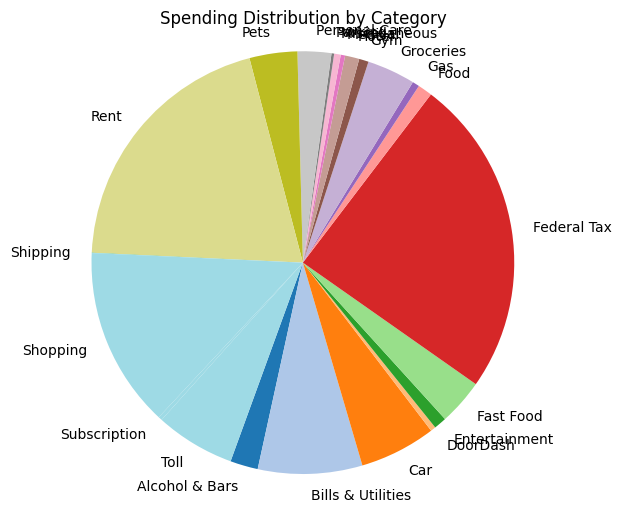

In [52]:
spending_by_category = fs.get_visualization_df(df, 1)
fs.show_pie_chart(spending_by_category)

# Analysis

### account Summary



account Pay: $9602.49
account Expense: $-8236.73
account Net: $1365.76





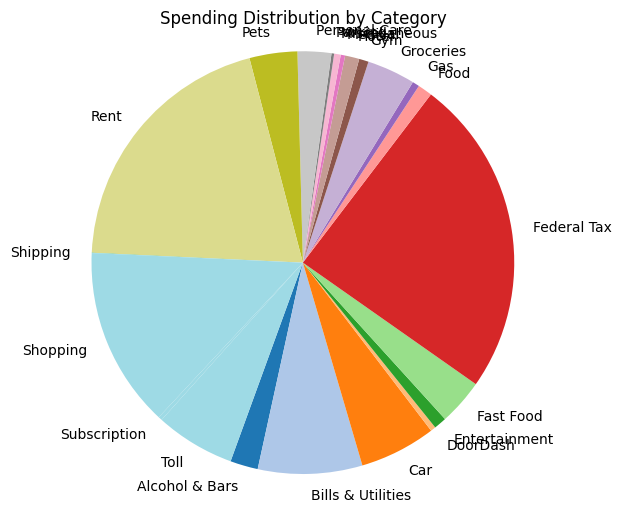

In [53]:
account_income = fs.get_income(account)
account_expense = fs.get_expenses(account)

# print_fancy(account)
fs.print_stats(account_income, account_expense, "account")
      
spending_by_category = fs.get_visualization_df(df, 1)
fs.show_pie_chart(spending_by_category)

In [55]:
fs.print_category(account, 'Shopping')

╒═════╤════════════╤════════════════════════╤══════════════════════════════════════════╤════════════╤══════════╤══════════╕
│     │ Date       │ Description            │ Original Description                     │ Category   │   Amount │ Status   │
╞═════╪════════════╪════════════════════════╪══════════════════════════════════════════╪════════════╪══════════╪══════════╡
│   0 │ 2025-10-31 │ Spirit Halloween       │ SPIRIT HALLOWEEN 60069   609-703-8292 TX │ Shopping   │   -49.75 │ Posted   │
├─────┼────────────┼────────────────────────┼──────────────────────────────────────────┼────────────┼──────────┼──────────┤
│  11 │ 2025-10-27 │ Spencer's              │ SPENCER GIFTS 440        868-284-0048 TX │ Shopping   │   -85.49 │ Posted   │
├─────┼────────────┼────────────────────────┼──────────────────────────────────────────┼────────────┼──────────┼──────────┤
│  14 │ 2025-10-27 │ Go Calendars Games Boo │ GO  CALENDARS GAMES BOO  AUSTIN       TX │ Shopping   │   -32.45 │ Posted   │
├─────┼─

# Visualizations

### Spending by Category

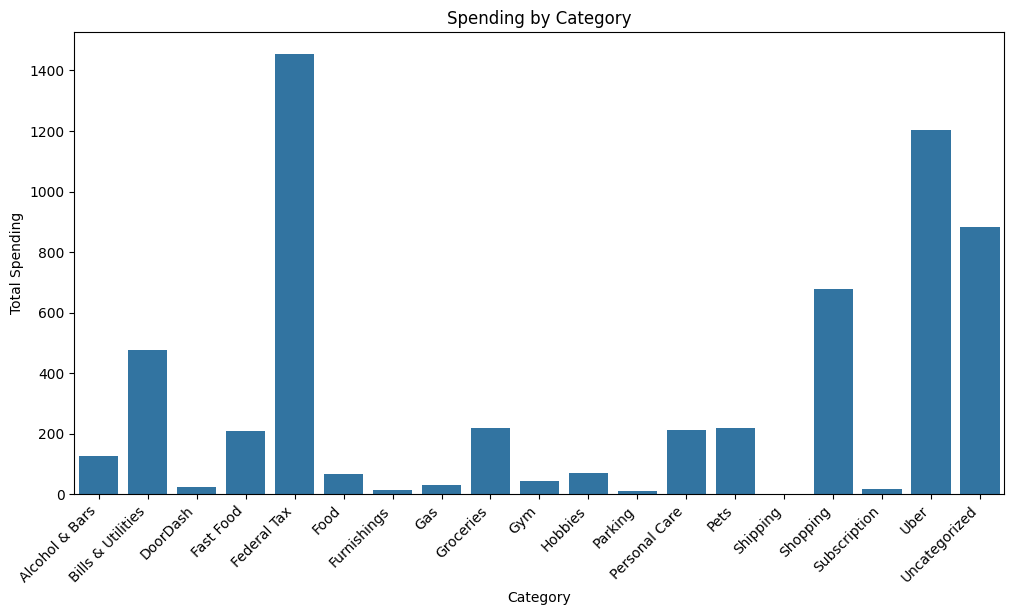

In [57]:
filtered_df = all[(all['Amount'] < 0) & (all['Category'] != 'Transfer')]
filtered_df.loc[:, 'Amount'] = filtered_df['Amount'].abs()
spending_by_category = filtered_df.groupby('Category')['Amount'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=spending_by_category.index, y=spending_by_category.values)
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Category')
plt.ylabel('Total Spending')
plt.title('Spending by Category')
plt.show()

In [ ]:
plt.figure(figsize=(12 ,12))
plt.pie(spending_by_category, labels=spending_by_category.index, startangle=250)
plt.axis('equal')
plt.title('Spending Distribution by Category')
plt.show()